# CardioIA - Phase 1: Exploratory Data Analysis (Numeric Dataset)

Simple exploratory analysis of `data/processed/cardioai_numeric_dataset.csv`, the Part 1 numeric dataset (920 patients from 4 hospitals, UCI Heart Disease Data Set).

Goal: get a first look at the data before it feeds into predictive models in later phases (missing values, distributions, target balance, and a quick check on the institution bias already noted in the README).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/cardioai_numeric_dataset.csv")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 920, Columns: 17


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,high_fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,exercise_st_depression,st_slope_peak_exercise,num_major_vessels,thalassemia,diagnosis_disease_0to4,sex_label,disease_presence,source_institution
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,M,0,Cleveland Clinic Foundation (USA)
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,M,1,Cleveland Clinic Foundation (USA)
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,M,1,Cleveland Clinic Foundation (USA)
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,M,0,Cleveland Clinic Foundation (USA)
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,F,0,Cleveland Clinic Foundation (USA)


## Data types and missing values

Missing values were left as empty cells during dataset generation (see `scripts/build_dataset.py`), mostly in `thalassemia` and `num_major_vessels` for the Swiss and Hungarian records.

In [2]:
df.info()

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(missing)

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    float64
 1   sex                       920 non-null    float64
 2   chest_pain_type           920 non-null    float64
 3   resting_blood_pressure    861 non-null    float64
 4   serum_cholesterol         890 non-null    float64
 5   high_fasting_blood_sugar  830 non-null    float64
 6   resting_ecg               918 non-null    float64
 7   max_heart_rate            865 non-null    float64
 8   exercise_induced_angina   865 non-null    float64
 9   exercise_st_depression    858 non-null    float64
 10  st_slope_peak_exercise    611 non-null    float64
 11  num_major_vessels         309 non-null    float64
 12  thalassemia               434 non-null    float64
 13  diagnosis_disease_0to4    920 non-null    int64  
 14  sex_label            

## Descriptive statistics

Summary statistics for the numeric columns.

In [3]:
df.describe()

,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,high_fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,exercise_st_depression,st_slope_peak_exercise,num_major_vessels,thalassemia,diagnosis_disease_0to4,disease_presence
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652,0.553261
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693,0.497426
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


## Target variable: disease presence

`disease_presence` is the binarized target (0 = no disease, 1 = disease present) that later phases will try to predict.

disease_presence
0    411
1    509
Name: count, dtype: int64


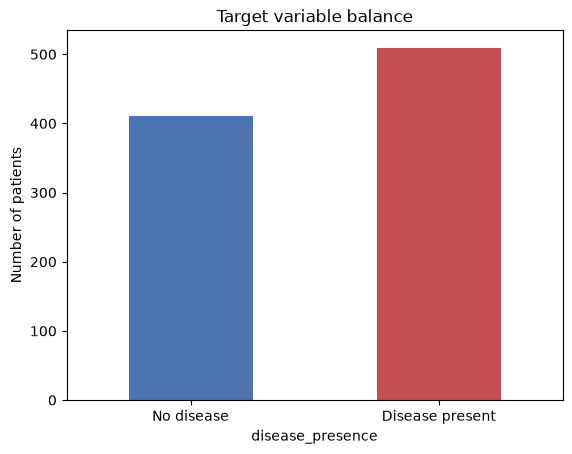

In [4]:
counts = df["disease_presence"].value_counts().sort_index()
print(counts)

counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.xticks([0, 1], ["No disease", "Disease present"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Target variable balance")
plt.show()

## Age distribution

Age distribution for the full sample, split by disease presence.

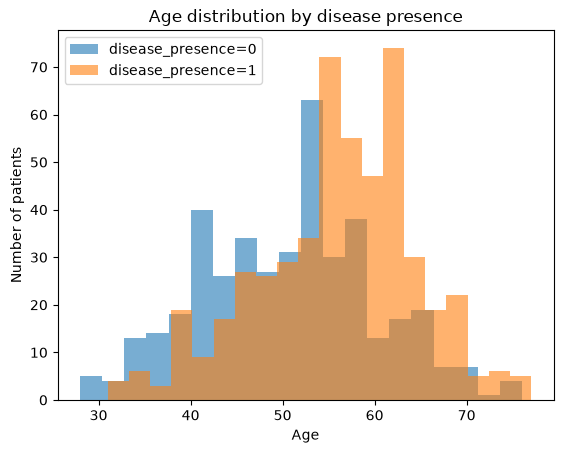

In [5]:
fig, ax = plt.subplots()
for label, group in df.groupby("disease_presence"):
    ax.hist(group["age"].dropna(), bins=20, alpha=0.6, label=f"disease_presence={label}")
ax.set_xlabel("Age")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution by disease presence")
ax.legend()
plt.show()

## Sex distribution vs. diagnosis

Cross-tab of `sex_label` against `disease_presence`, mentioned in the README as a non-modifiable risk factor.

disease_presence   0    1
sex_label                
F                 72   25
M                 92  114

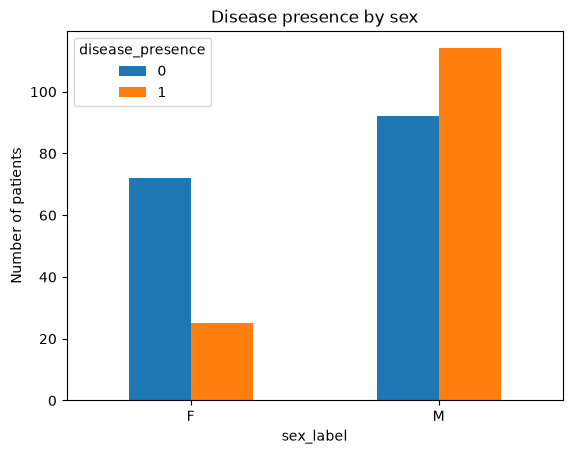

In [6]:
cross = pd.crosstab(df["sex_label"], df["disease_presence"])
print(cross)

cross.plot(kind="bar")
plt.ylabel("Number of patients")
plt.title("Disease presence by sex")
plt.legend(title="disease_presence")
plt.xticks(rotation=0)
plt.show()

## Key clinical variables by diagnosis

Boxplots of resting blood pressure, serum cholesterol and max heart rate, split by disease presence. These are the variables the README flags as clinically relevant.

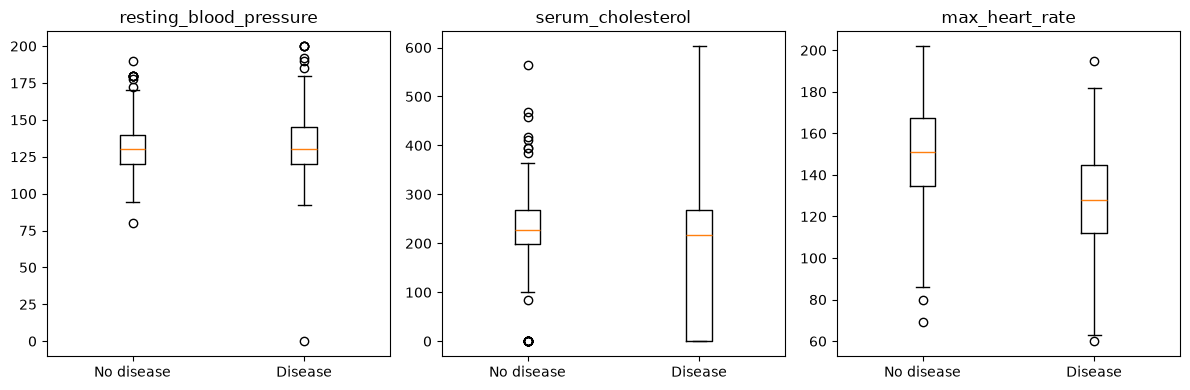

In [7]:
columns_to_plot = ["resting_blood_pressure", "serum_cholesterol", "max_heart_rate"]

fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(12, 4))
for ax, col in zip(axes, columns_to_plot):
    data_by_target = [
        df.loc[df["disease_presence"] == 0, col].dropna(),
        df.loc[df["disease_presence"] == 1, col].dropna(),
    ]
    ax.boxplot(data_by_target, tick_labels=["No disease", "Disease"])
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Source institution bias check

Since the dataset combines 4 hospitals from different countries, this checks whether diagnosis prevalence differs by institution, the population bias already discussed in the README governance section.

                                                 disease_rate  num_patients
source_institution                                                         
University Hospital, Zurich/Basel (Switzerland)      0.934959           123
V.A. Medical Center, Long Beach (USA)                0.745000           200
Cleveland Clinic Foundation (USA)                    0.458746           303
Hungarian Institute of Cardiology, Budapest          0.360544           294


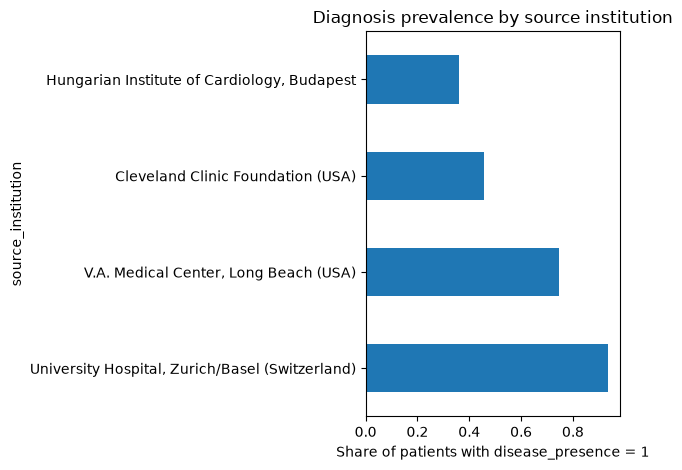

In [8]:
institution_rate = df.groupby("source_institution")["disease_presence"].agg(["mean", "count"])
institution_rate = institution_rate.rename(columns={"mean": "disease_rate", "count": "num_patients"})
institution_rate = institution_rate.sort_values("disease_rate", ascending=False)
print(institution_rate)

institution_rate["disease_rate"].plot(kind="barh")
plt.xlabel("Share of patients with disease_presence = 1")
plt.title("Diagnosis prevalence by source institution")
plt.tight_layout()
plt.show()

## Takeaways

- The dataset has 920 rows and no duplicate structure issues; missing values are concentrated in `thalassemia` and `num_major_vessels`.
- The target variable is reasonably balanced between the two classes.
- Age, chest pain type related variables, and max heart rate show visible separation between patients with and without disease, consistent with the clinical relevance discussed in the README.
- Diagnosis prevalence differs noticeably by source institution, confirming the population bias already flagged in the README governance section. Any model trained on this data in later phases should account for that before generalizing across populations.